# Tutorial completo: estimación e inferencia en modelos de difusión con saltos

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jdospina/jump-diffusion-estimation/blob/main/notebooks/tutorial_completo.ipynb)

Este es el tutorial de referencia de la librería `jump-diffusion-estimation`. Recorre el flujo completo de trabajo, de principio a fin:

1. **Simular** una trayectoria de difusión con saltos.
2. **Estimar** los parámetros por máxima verosimilitud, con optimización local (L-BFGS-B) y global (Evolución Diferencial).
3. **Cuantificar la incertidumbre** con las tres rutas de inferencia: profile likelihood, Wald y bootstrap paramétrico.
4. **Contrastar la presencia de saltos** con un test formal ($H_0: p = 0$).
5. **Comparar distribuciones de salto** y evaluar la bondad de ajuste.

Al terminar sabrás usar toda la superficie principal de la librería. Para ejemplos aplicados más específicos, ver los notebooks `differential_evolution_showcase` y `sp500_jump_diffusion_example`.

## 1. Preparación del entorno

La siguiente celda instala la librería **solo si hace falta** (por ejemplo, en Google Colab). Si ya la tienes instalada, no hace nada.

In [1]:
import importlib.util, subprocess, sys

if importlib.util.find_spec('jump_diffusion') is None:
    subprocess.run(
        [sys.executable, '-m', 'pip', 'install', '-q',
         'git+https://github.com/jdospina/jump-diffusion-estimation.git'],
        check=True,
    )

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from jump_diffusion import JumpDiffusionSimulator, JumpDiffusionEstimator
from jump_diffusion.distributions import (
    NormalJump, SkewNormalJump, SGEDJump, KouJump, StudentTJump,
)
from jump_diffusion.validation import JumpDistributionComparison

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 30)
np.set_printoptions(suppress=True)

## 2. El modelo

Trabajamos con un proceso de difusión con saltos

$$dX_t = \mu\, dt + \sigma\, dW_t + J_t\, dN_t,$$

donde $W_t$ es un movimiento browniano, $N_t$ cuenta los saltos (aproximado por ensayos de Bernoulli, a lo sumo un salto por paso) y $J_t$ es el **tamaño del salto**, con una distribución que tú eliges (normal, skew-normal, SGED, Kou, Student-t, ...).

Sobre datos discretos, la densidad de cada incremento es una **mixtura** de dos componentes: sin salto (con probabilidad $1-p$) y con salto (con probabilidad $p$):

$$g(\Delta x) = (1-p)\,\mathcal{N}(\mu\,\Delta t, \sigma^2 \Delta t) + p\,\big[\mathcal{N}(\mu\,\Delta t, \sigma^2 \Delta t) * f_J\big].$$

La estimación por máxima verosimilitud usa exactamente esta mixtura.

## 3. Simular una trayectoria

Generamos una serie con saltos **asimétricos** (skew-normal). Los parámetros están en escala anual y usamos pasos diarios ($\Delta t = 1/252$).

In [3]:
dt = 1.0 / 252
n_steps = 750  # ~3 anios de datos diarios

simulator = JumpDiffusionSimulator(
    mu=0.05, sigma=0.2, jump_prob=0.08,
    jump_distribution=SkewNormalJump(), jump_scale=0.15, jump_skew=3.0,
)
times, path, jump_component = simulator.simulate_path(
    T=n_steps * dt, n_steps=n_steps, x0=100.0, seed=42,
)
increments = np.diff(path)
print(f'{len(increments)} incrementos, dt = {dt:.5f}')

750 incrementos, dt = 0.00397


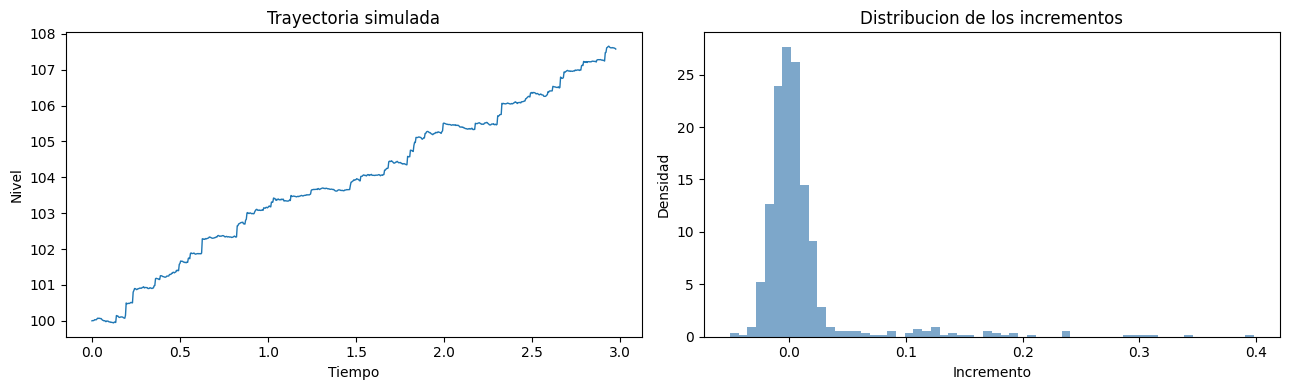

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(times, path, lw=1)
ax1.set_title('Trayectoria simulada')
ax1.set_xlabel('Tiempo'); ax1.set_ylabel('Nivel')
ax2.hist(increments, bins=60, density=True, alpha=0.7, color='steelblue')
ax2.set_title('Distribucion de los incrementos')
ax2.set_xlabel('Incremento'); ax2.set_ylabel('Densidad')
plt.tight_layout()

## 4. Estimar los parámetros

Creamos un estimador declarando la **misma familia de salto** que queremos ajustar (aquí, skew-normal). El método por defecto es L-BFGS-B (optimización local, rápida).

In [5]:
estimator = JumpDiffusionEstimator(
    increments, dt, jump_distribution=SkewNormalJump(),
)
result = estimator.estimate()  # L-BFGS-B por defecto
print('Convergencia:', result['convergence'])
print('Log-verosimilitud:', round(result['log_likelihood'], 2))
pd.Series(result['parameters']).round(4)

Convergencia: True
Log-verosimilitud: 1920.86


mu           -0.0467
sigma         0.1985
jump_prob     0.0917
jump_scale    0.1461
jump_skew     4.0969
dtype: float64

### Optimización global con Evolución Diferencial

La verosimilitud de la mixtura es **multimodal**: los métodos de gradiente pueden quedar atrapados si el arranque es malo. La Evolución Diferencial (global, poblacional) es mucho más robusta a un conocimiento previo pobre, a costa de más evaluaciones. Es el hallazgo central de Ardia, Ospina & Giraldo (2011).

In [6]:
result_de = estimator.estimate(method='differential_evolution', seed=1)
print('Convergencia (DE):', result_de['convergence'])
pd.DataFrame({
    'verdadero': {'mu': 0.05, 'sigma': 0.2, 'jump_prob': 0.08,
                  'jump_scale': 0.15, 'jump_skew': 3.0},
    'L-BFGS-B': result['parameters'],
    'DE': result_de['parameters'],
}).round(4)

Convergencia (DE): True


,verdadero,L-BFGS-B,DE
mu,0.05,-0.0467,-0.0468
sigma,0.20,0.1985,0.1985
jump_prob,0.08,0.0917,0.0917
jump_scale,0.15,0.1461,0.1461
jump_skew,3.00,4.0969,4.0972


## 5. Inferencia: las tres rutas, lado a lado

El punto estimado no basta: necesitamos **cuantificar la incertidumbre**. La librería ofrece tres rutas complementarias:

| Ruta | Método | Cuándo brilla |
|------|--------|---------------|
| **Profile** | Perfil de verosimilitud (Wilks) | Intervalos asimétricos respetando la geometria de la verosimilitud |
| **Wald** | Información de Fisher observada | Barata; simétrica; válida lejos de las fronteras |
| **Bootstrap** | Bootstrap paramétrico | Sin supuestos asintóticos; la más fiable cerca de fronteras (p. ej. $p \to 0$) |

Las calculamos y luego `summary()` las junta en una sola tabla.

In [7]:
estimator.estimate_standard_errors(n_points=7)              # profile
estimator.estimate_wald_standard_errors()                   # Wald
estimator.estimate_bootstrap_standard_errors(n_bootstrap=99, seed=0)  # bootstrap

estimator.summary().round(4)

,parameter,estimate,profile_se,profile_ci_low,profile_ci_high,wald_se,wald_ci_low,wald_ci_high,bootstrap_se,bootstrap_ci_low,bootstrap_ci_high
0,mu,-0.0468,0.1255,-0.2909,0.1980,0.1274,-0.2964,0.2029,0.1214,-0.3047,0.1279
1,sigma,0.1985,0.0061,0.1878,0.2106,0.0062,0.1864,0.2107,0.0057,0.1886,0.2093
2,jump_prob,0.0917,0.0122,0.0711,0.1173,0.0124,0.0674,0.1160,0.0127,0.0689,0.1178
3,jump_scale,0.1461,0.0129,0.1240,0.1747,0.0135,0.1196,0.1726,0.0154,0.1164,0.1754
4,jump_skew,4.0972,1.5589,2.3261,10.0000,1.6203,0.9215,7.2729,2.7978,2.5027,10.0000


Las tres columnas de error estándar deberían ser parecidas para los parámetros bien identificados (como $\sigma$) y divergir donde la identificación es más débil. Podemos visualizar el perfil de verosimilitud de cada parámetro, con el umbral de Wilks del 95%:

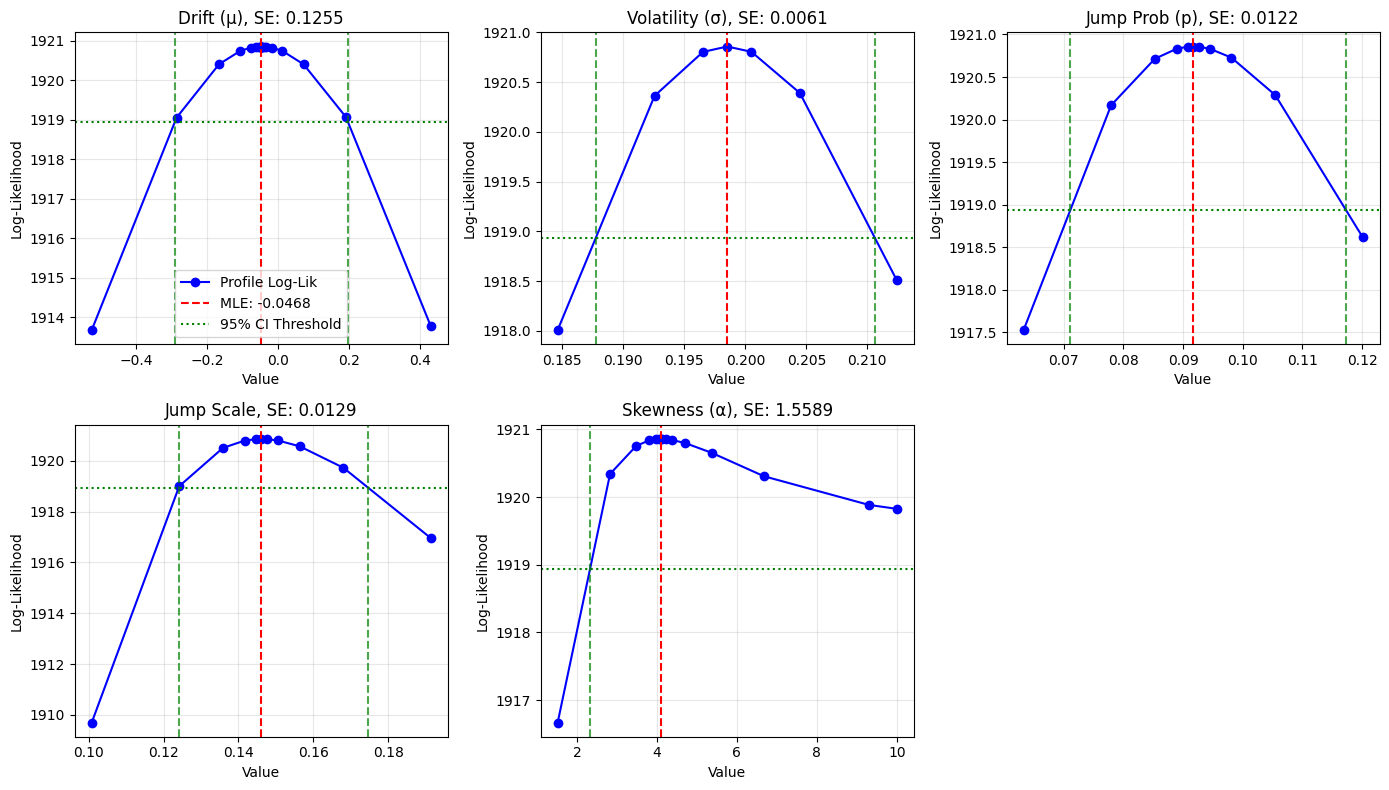

In [8]:
estimator.plot_profiles(figsize=(14, 8))

## 6. ¿Hay saltos? Un test formal

Contrastamos $H_0: p = 0$ (difusión pura) frente a $H_1: p > 0$. Este test es **no estándar**: bajo la nula, la probabilidad de salto está en la frontera del espacio de parámetros **y** los parámetros de la distribución de salto quedan sin identificar. Por eso el p-valor se obtiene por **bootstrap paramétrico**, no por una $\chi^2$.

In [9]:
jump_test = estimator.test_for_jumps(n_bootstrap=99, seed=0)
print(f"Estadistico LR: {jump_test['lr_statistic']:.2f}")
print(f"p-valor (bootstrap): {jump_test['p_value']:.4f}")
veredicto = 'Se rechaza H0: hay evidencia de saltos.' \
    if jump_test['p_value'] < 0.05 else 'No se rechaza H0.'
print(veredicto)

Estadistico LR: 1312.19
p-valor (bootstrap): 0.0100
Se rechaza H0: hay evidencia de saltos.


## 7. Comparar distribuciones de salto

¿Qué ley de salto describe mejor los datos? `JumpDistributionComparison` ajusta varias candidatas sobre los mismos datos y las rankea por AIC/BIC y por un test de Kolmogorov-Smirnov cuyo p-valor se calcula por **bootstrap paramétrico** (por lo que tiene en cuenta que los parámetros se estimaron de los mismos datos).

In [10]:
comparison = JumpDistributionComparison(increments, dt)
candidatas = {
    'Normal': NormalJump(),
    'SkewNormal': SkewNormalJump(),
    'SGED': SGEDJump(),
    'Kou': KouJump(),
    'StudentT': StudentTJump(),
}
for nombre, dist in candidatas.items():
    comparison.fit(nombre, dist, seed=1, n_bootstrap=49, ks_reference_size=5000)

comparison.compare().round(4)

,distribution,log_likelihood,aic,bic,ks_statistic,ks_pvalue,convergence
0,SkewNormal,1920.8584,-3831.7167,-3808.6164,0.0272,0.4000,True
1,SGED,1921.3249,-3828.6497,-3796.3092,0.0283,0.2703,True
2,Kou,1917.7311,-3823.4621,-3795.7417,0.0258,0.4800,True
3,StudentT,1917.5919,-3823.1837,-3795.4633,0.0204,0.8200,True
4,Normal,1887.9639,-3767.9277,-3749.4474,0.0417,0.0200,True


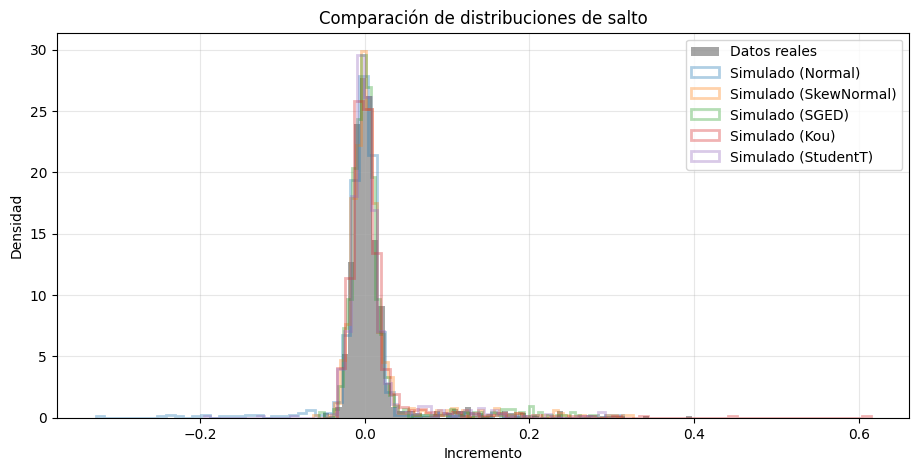

In [11]:
comparison.plot_comparison(bins=60, figsize=(11, 5))

## 8. Resumen del ajuste

`diagnostics()` imprime un resumen legible del ajuste, incluyendo la comparación entre los momentos empíricos y los teóricos del modelo.

In [12]:
estimator.diagnostics()

JUMP-DIFFUSION ESTIMATION RESULTS
Parameter          | Estimate   | Std Error  | 95% Conf. Interval    
--------------------------------------------------------------------
mu                 | -0.046752  | 0.125473   | [-0.2909, 0.1980]     
sigma              | 0.198518   | 0.006069   | [0.1878, 0.2106]      
jump_prob          | 0.091685   | 0.012198   | [0.0711, 0.1173]      
jump_scale         | 0.146113   | 0.012881   | [0.1240, 0.1747]      
jump_skew          | 4.097229   | 1.558889   | [2.3261, 10.0000]     

Log-likelihood:         1920.86
AIC:                    -3831.72
BIC:                    -3808.62
Convergence:            True

DATA vs MODEL COMPARISON
------------------------------
Mean increment:
  Empirical:  0.010098
  Theoretical: -0.000186
Std deviation:
  Empirical:  0.044812
  Theoretical: 0.045976
Expected jumps: 68.8


## 9. Resumen y siguientes pasos

En este tutorial recorriste el flujo completo: **simular -> estimar (local y global) -> inferir por tres rutas -> testear saltos -> comparar distribuciones**.

Ideas para seguir:

- Repite el análisis con datos reales (ver `sp500_jump_diffusion_example`).
- Cambia la familia de salto y observa cómo cambian el AIC/BIC y el KS.
- Compara la **cobertura** de los intervalos profile / Wald / bootstrap vía Monte Carlo.

### Referencias

- Merton (1976); Kou (2002) — modelos de difusión con saltos.
- Storn & Price (1997); Ardia, Ospina & Giraldo (2011) — Evolución Diferencial.
- Wilks (1938); Efron & Hinkley (1978) — inferencia por verosimilitud.
- Ospina Arango (2009) — tesis de maestria (SGED, convolución por FFT, algoritmos evolutivos).